In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


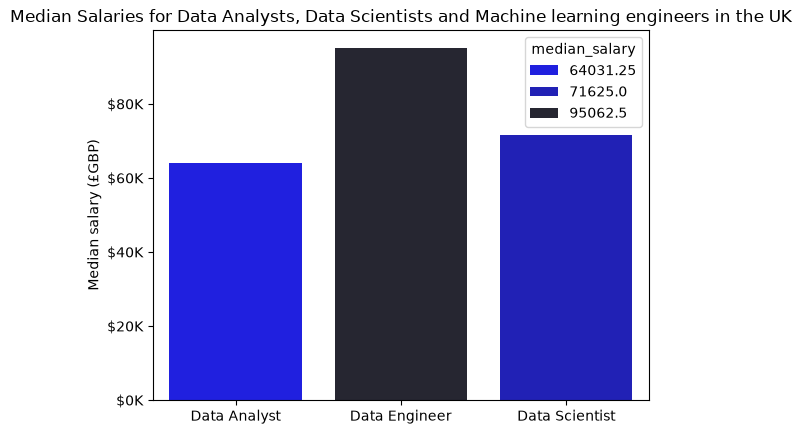

In [12]:

df_UK = df[(df['job_title_short'].isin(['Data Engineer', 'Data Analyst', 'Data Scientist']))&
            (df['job_country'] == 'United Kingdom')].dropna(subset = ['salary_year_avg'])

df_UK['salary_year_avg'] = df_UK['salary_year_avg']*0.75

df_UK_group = (
    df_UK.groupby('job_title_short')['salary_year_avg']
                .median()
                .reset_index(name = 'median_salary')                
)

sns.barplot(data = df_UK_group,
             x = 'job_title_short',
               y = 'median_salary',
                   palette = 'dark:b_r',
                   hue = 'median_salary')
plt.xlabel('')
plt.ylabel('Median salary (£GBP)')
plt.title('Median Salaries for Data Analysts, Data Scientists and Machine learning engineers in the UK')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.show()

In [17]:
df_UK[(df_UK['job_title_short'] == 'Data Engineer') & (df_UK['job_posted_date'].dt.year == 2025)].reset_index()
      

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,1322005,Data Engineer,Resident Solutions Architect – Data Engineerin...,"Washington, United Kingdom",Vaia,Full-time,False,United Kingdom,2025-01-27 07:12:32,False,False,United Kingdom,year,67500.0,NaN,DataBricks,"[python, scala, databricks, aws, azure, gcp, s...","{'cloud': ['databricks', 'aws', 'azure', 'gcp'..."
1,1344786,Data Engineer,Data Platform Engineer (Azure),"London, United Kingdom",Aptrack.co,Full-time,False,United Kingdom,2025-02-03 16:32:15,True,False,United Kingdom,year,187500.0,NaN,Trust in SODA,"[sql, python, nosql, mongodb, mongodb, postgre...","{'cloud': ['azure', 'databricks'], 'databases'..."
2,1344788,Data Engineer,Data Engineer -Abu Dhabi Hedge Fund,United Kingdom,LinkedIn,Full-time,False,United Kingdom,2025-02-03 16:32:16,True,False,United Kingdom,year,225000.0,NaN,Saragossa,NaN,NaN
3,1489127,Data Engineer,"Manager, Data Engineer - AI and Automation",Anywhere,Built In Boston,Full-time,True,United Kingdom,2025-04-02 06:35:56,False,True,United Kingdom,year,96112.5,NaN,Pfizer,"[python, sql, java, scala, neo4j, elasticsearc...","{'cloud': ['redshift', 'bigquery', 'snowflake'..."
4,1505286,Data Engineer,AI Data Engineering Lead,"London, United Kingdom",LinkedIn,Full-time,False,United Kingdom,2025-04-09 13:35:14,False,False,United Kingdom,year,262500.0,NaN,Moonvalley,"[python, spark, airflow, kubernetes, terraform]","{'libraries': ['spark', 'airflow'], 'other': [..."
5,1609250,Data Engineer,Sr. Data Engineer,"Salisbury, United Kingdom",Vaia – Talents,Full-time and Part-time,False,United Kingdom,2025-07-06 06:08:16,False,False,United Kingdom,year,127500.0,NaN,Capital One,"[java, scala, python, nosql, sql, mongo, shell...","{'cloud': ['redshift', 'snowflake', 'aws', 'az..."
6,1621335,Data Engineer,NEW IN| Data Engineer | High visibility and be...,United Kingdom,LinkedIn,Full-time,False,United Kingdom,2025-07-17 16:39:07,True,False,United Kingdom,year,93750.0,NaN,Data Revolution,"[sql, python, snowflake, databricks]","{'cloud': ['snowflake', 'databricks'], 'progra..."
7,1628835,Data Engineer,Sr. Data Engineer,United Kingdom,Jobgether,Full-time,False,United Kingdom,2025-07-25 06:16:50,False,False,United Kingdom,year,108750.0,NaN,Goodwin,"[sql, python, powershell, t-sql, c#, html, css...","{'analyst_tools': ['ssis', 'ssrs', 'tableau'],..."
8,1637382,Data Engineer,"Data Engineer, Senior","Huntingdon, United Kingdom",BeBee GB,Full-time,False,United Kingdom,2025-08-03 20:15:46,True,False,United Kingdom,year,95062.5,NaN,Booz Allen Hamilton,"[java, python, r]","{'programming': ['java', 'python', 'r']}"
9,1637384,Data Engineer,"Data Engineer, Senior","Peterborough, United Kingdom",BeBee GB,Full-time,False,United Kingdom,2025-08-03 20:15:47,True,False,United Kingdom,year,95062.5,NaN,Booz Allen Hamilton,"[java, python, r]","{'programming': ['java', 'python', 'r']}"


In [16]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,NaN,NaN,NaN,Metasys Technologies,"[sql, snowflake, visio, jira, confluence]","{'analyst_tools': ['visio'], 'async': ['jira',..."
1,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:22,False,True,United States,NaN,NaN,NaN,Guidehouse,"[sql, python, r, azure, snowflake, databricks,...","{'analyst_tools': ['tableau', 'excel'], 'cloud..."
2,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:24,False,False,United States,NaN,NaN,NaN,Protask,"[sql, jira]","{'async': ['jira'], 'programming': ['sql']}"
3,Senior Data Analyst,Senior Data Analyst / Platform Experience,"Worcester, MA",via LinkedIn,Full-time,False,"New York, United States",2023-01-01 00:00:27,False,True,United States,NaN,NaN,NaN,Atria Wealth Solutions,"[sql, atlassian, jira]","{'async': ['jira'], 'other': ['atlassian'], 'p..."
4,Data Analyst,Jr. Data Analyst,"Torrance, CA",via Recruit.net,Full-time,False,"California, United States",2023-01-01 00:00:38,False,False,United States,NaN,NaN,NaN,Aquent,[excel],{'analyst_tools': ['excel']}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780664,Data Scientist,Sr Data Scientist,"San Jose, CA",ZipRecruiter,Full-time,False,"California, United States",2025-12-31 23:02:36,False,True,United States,year,178175.0,NaN,PayPal,"[sql, python, bigquery, jupyter, hadoop]","{'cloud': ['bigquery'], 'libraries': ['jupyter..."
1780665,Senior Data Engineer,"Senior Software Engineer, Data Ecosystem","London, ON, Canada",BeBee CA,Full-time,False,Canada,2025-12-31 23:12:59,True,False,Canada,NaN,NaN,NaN,Menlo Ventures,NaN,NaN
1780666,Business Analyst,"Analyst, Business Performance (EVCI &#038; H2)",Abu Dhabi - United Arab Emirates,LinkedIn,Contractor,False,United Arab Emirates,2025-12-31 23:13:45,False,False,United Arab Emirates,NaN,NaN,NaN,MyPetroCareer.com,"[excel, powerpoint, word]","{'analyst_tools': ['excel', 'powerpoint', 'wor..."
1780667,Business Analyst,Strategy and business analyst,U.S. Virgin Islands,Recruit.net,Full-time,False,U.S. Virgin Islands,2025-12-31 23:31:12,False,False,U.S. Virgin Islands,NaN,NaN,NaN,Randstad Italia,"[gdpr, excel]","{'analyst_tools': ['excel'], 'libraries': ['gd..."
